In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41971,Workers: 12
Dashboard: http://127.0.0.1:8787/status,Total threads: 96
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:43419,Total threads: 8
Dashboard: http://127.0.0.1:41461/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:33421,


2025-11-04 10:50:57,627 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f22d18ab060>, <Task finished name='Task-1370872' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniconda3/envs/mitgcm_analysis/lib/python3.12/site-packages/distributed/comm/tcp.py:654> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniconda3/envs/mitgcm_analysis/lib/python3.12/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniconda3/envs/mitgcm_analysis/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniconda3/envs/mitgcm_analysis/lib/python3.12/site-packages/distributed/comm/tcp.py", line

### Load MITgcm Output from Assimilations (with and without velocity)

In [32]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/TPOSE_TAO/sep2012/compare_with_without_vel/'

In [2]:
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_withhold/run_iter14/'

## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags+1,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
ds_vel = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds_vel['XC'] = ds_vel.XC.astype(float)
ds_vel['YC'] = ds_vel.YC.astype(float)
ds_vel['Z'] = ds_vel.Z.astype(float)
ds_vel['XG'] = ds_vel.XG.astype(float)
ds_vel['YG'] = ds_vel.YG.astype(float)

### Load TAO Data (T and S)

In [105]:
lon_str = '170'

In [106]:
TAO_T_file = '/data/SO3/edavenport/TAO_2012to2016_daily/T_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_T = xr.open_dataset(TAO_T_file)
TAO_S_file = '/data/SO3/edavenport/TAO_2012to2016_daily/S_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_S = xr.open_dataset(TAO_S_file)
dsTAO = xr.merge([dsTAO_T,dsTAO_S])

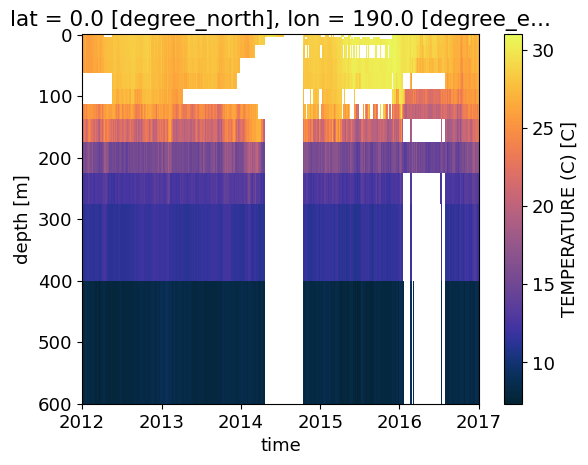

In [107]:
dsTAO.T_20.plot(x='time',cmap=cmo.thermal,yincrease=False)

In [108]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2012-12-31')) # subset to sep-dec 2012
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XC'})

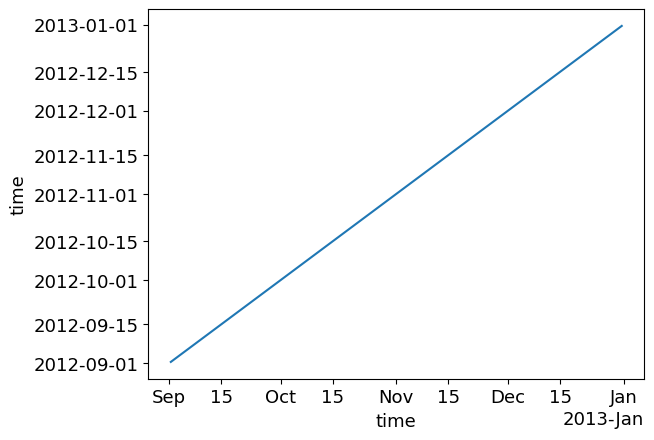

In [109]:
dsTAO.time.plot()

In [110]:
tpose_T = ds.THETA.interp_like(dsTAO.T_20).compute().squeeze()
tpose_S = ds.SALT.interp_like(dsTAO.S_41).compute().squeeze()
tpose_T_vel = ds_vel.THETA.interp_like(dsTAO.T_20).compute().squeeze()
tpose_S_vel = ds_vel.SALT.interp_like(dsTAO.S_41).compute().squeeze()

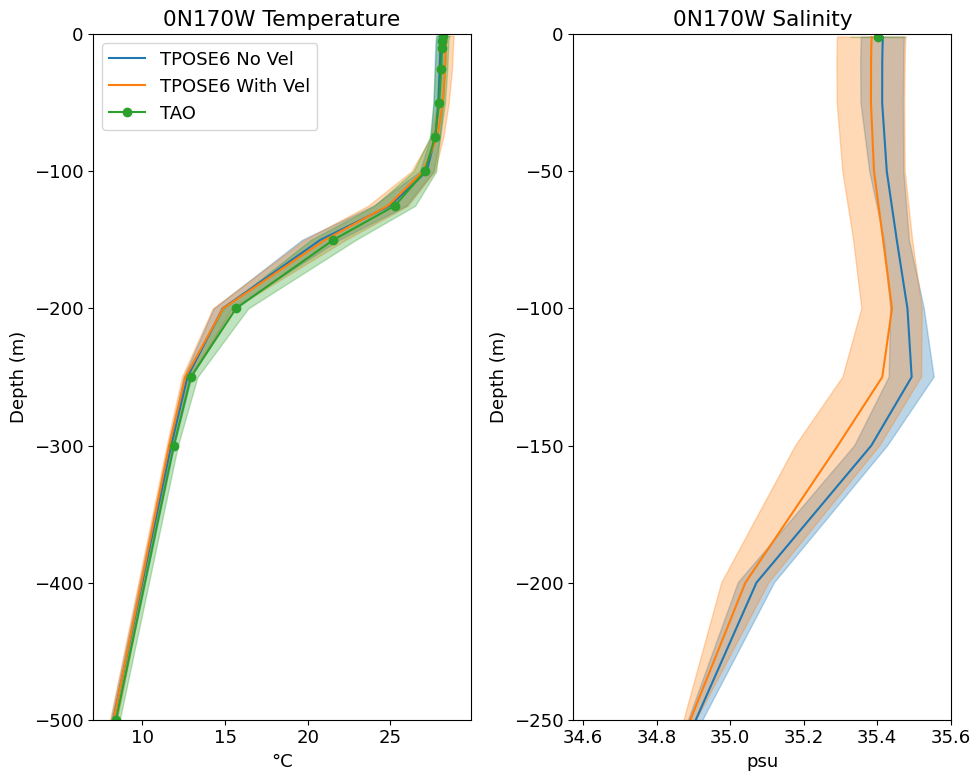

In [111]:
fig,ax = plt.subplots(figsize=(10,8),ncols=2)
tpose_T.mean(dim='time').plot(ax=ax[0],y='Z',label='TPOSE6 No Vel')
ax[0].fill_betweenx(tpose_T.Z,tpose_T.mean(dim='time')-tpose_T.std(dim='time'),tpose_T.mean(dim='time')+tpose_T.std(dim='time'),color='C0',alpha=0.3)
tpose_T_vel.mean(dim='time').plot(ax=ax[0],y='Z',label='TPOSE6 With Vel')
ax[0].fill_betweenx(tpose_T_vel.Z,tpose_T_vel.mean(dim='time')-tpose_T_vel.std(dim='time'),tpose_T_vel.mean(dim='time')+tpose_T_vel.std(dim='time'),color='C1',alpha=0.3)

TAO_mean = dsTAO.T_20.mean(dim='time').squeeze()
TAO_std = dsTAO.T_20.std(dim='time').squeeze()
TAO_mean.plot(ax=ax[0],y='Z',label='TAO',marker='o')
ax[0].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C2',alpha=0.3)

ax[0].set_title('0N'+ lon_str +'W Temperature')
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('°C')
ax[0].legend()
ax[0].set_ylim(-500,0)

tpose_S.mean(dim='time').plot(ax=ax[1],y='Z',label='TPOSE6 No Vel')
ax[1].fill_betweenx(tpose_S.Z,tpose_S.mean(dim='time')-tpose_S.std(dim='time'),tpose_S.mean(dim='time')+tpose_S.std(dim='time'),color='C0',alpha=0.3)
tpose_S_vel.mean(dim='time').plot(ax=ax[1],y='Z',label='TPOSE6 With Vel')
ax[1].fill_betweenx(tpose_S_vel.Z,tpose_S_vel.mean(dim='time')-tpose_S_vel.std(dim='time'),tpose_S_vel.mean(dim='time')+tpose_S_vel.std(dim='time'),color='C1',alpha=0.3)
TAO_mean = dsTAO.S_41.mean(dim='time').squeeze()
TAO_std = dsTAO.S_41.std(dim='time').squeeze()
TAO_mean.plot(ax=ax[1],y='Z',label='TAO',marker='o')
ax[1].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C2',alpha=0.3)
ax[1].set_title('0N'+ lon_str +'W Salinity')
ax[1].set_ylabel('Depth (m)')
ax[1].set_xlabel('psu')
ax[1].set_ylim(-250,0)

plt.tight_layout()
fig.savefig(foldername+'TS_' + lon_str + 'W_mean_prof.png')

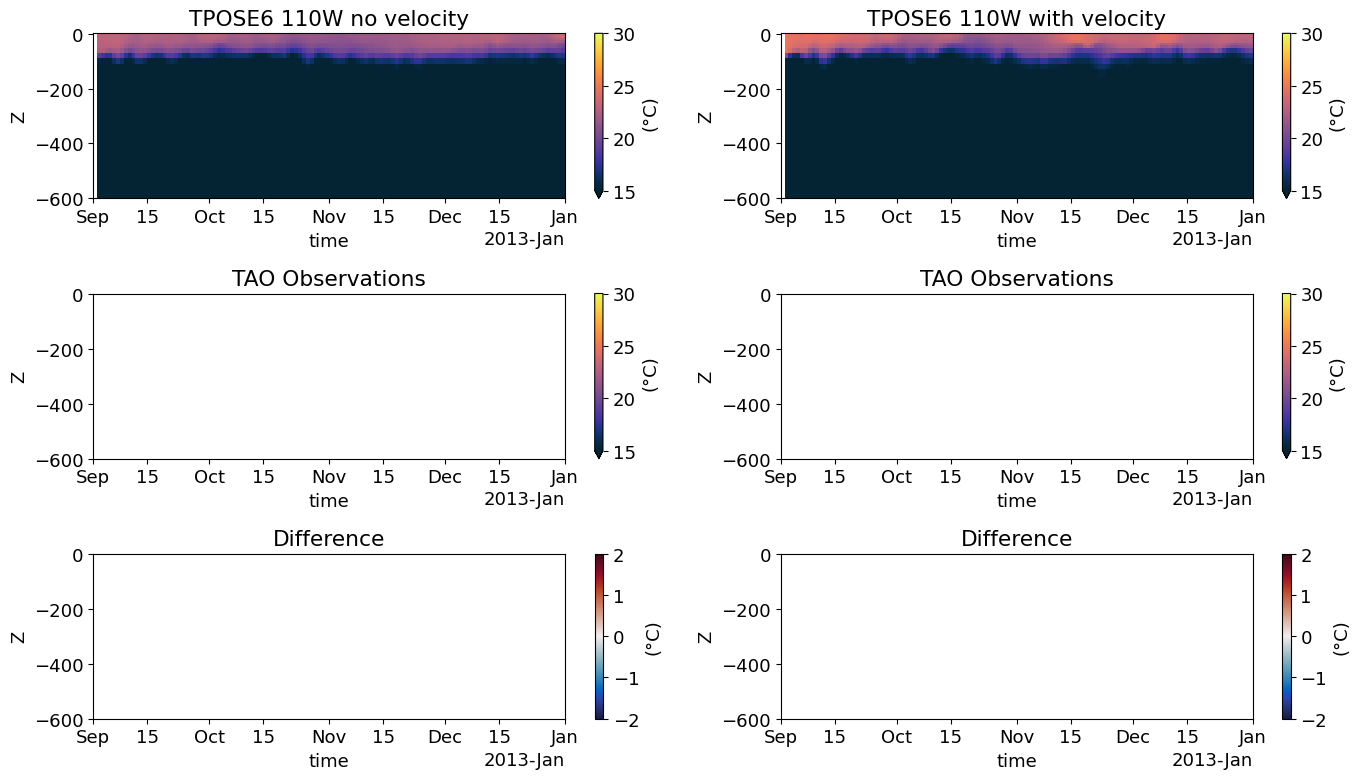

In [53]:
fig, ax = plt.subplots(figsize=(14,8),nrows=3,ncols=2)
tpose_T.plot(ax=ax[0,0],cmap=cmo.thermal,vmin=15,vmax=30,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[0,0].set_title('TPOSE6 ' + lon_str + 'W no velocity')
tpose_T_vel.plot(ax=ax[0,1],cmap=cmo.thermal,vmin=15,vmax=30,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[0,1].set_title('TPOSE6 ' + lon_str + 'W with velocity')
dsTAO.T_20.plot(ax=ax[1,0],cmap=cmo.thermal,vmin=15,vmax=30,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[1,0].set_title('TAO Observations')
dsTAO.T_20.plot(ax=ax[1,1],cmap=cmo.thermal,vmin=15,vmax=30,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[1,1].set_title('TAO Observations')
(tpose_T - dsTAO.T_20).plot(ax=ax[2,0],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[2,0].set_title('Difference')
(tpose_T_vel - dsTAO.T_20).plot(ax=ax[2,1],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[2,1].set_title('Difference')
plt.tight_layout()
fig.savefig(foldername+'T_' + lon_str + 'W.png')


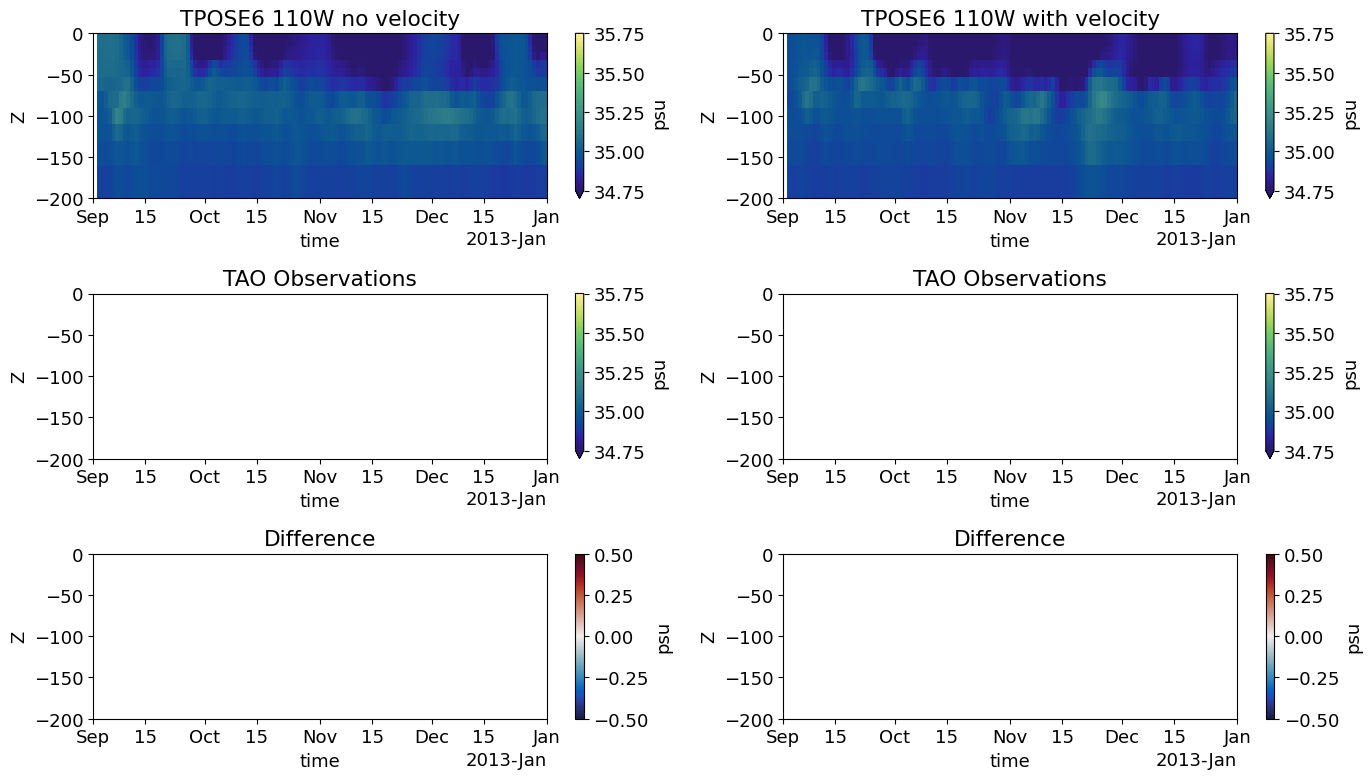

In [54]:
fig, ax = plt.subplots(figsize=(14,8),nrows=3,ncols=2)
tpose_S.plot(ax=ax[0,0],cmap=cmo.haline,vmin=34.75,vmax=35.75,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[0,0].set_title('TPOSE6 ' + lon_str + 'W no velocity')
ax[0,0].set_ylim(-200,0)
tpose_S_vel.plot(ax=ax[0,1],cmap=cmo.haline,vmin=34.75,vmax=35.75,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[0,1].set_title('TPOSE6 ' + lon_str + 'W with velocity')
ax[0,1].set_ylim(-200,0)
dsTAO.S_41.plot(ax=ax[1,0],cmap=cmo.haline,vmin=34.75,vmax=35.75,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[1,0].set_title('TAO Observations')
ax[1,0].set_ylim(-200,0)
dsTAO.S_41.plot(ax=ax[1,1],cmap=cmo.haline,vmin=34.75,vmax=35.75,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[1,1].set_title('TAO Observations')
ax[1,1].set_ylim(-200,0)
(tpose_S - dsTAO.S_41).plot(ax=ax[2,0],cmap=cmo.balance,vmin=-0.5,vmax=0.5,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[2,0].set_title('Difference')
ax[2,0].set_ylim(-200,0)
(tpose_S_vel - dsTAO.S_41).plot(ax=ax[2,1],cmap=cmo.balance,vmin=-0.5,vmax=0.5,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[2,1].set_title('Difference')
ax[2,1].set_ylim(-200,0)
plt.tight_layout()
fig.savefig(foldername+'S_' + lon_str + 'W.png')

In [3]:
client.shutdown()
cluster.close()
client.close()